# SEM Sampling Backend Profiling

**Note:** To run this notebook end-to-end you must have the optional JAX backends installed, e.g. `conda install jax numpyro blackjax`.

This notebook profiles a fixed Spatial Error Model (SEM) across PyMC sampling backends, mirroring [`sampling_backend_profiling.ipynb`](sampling_backend_profiling.ipynb) (the SAR version). It additionally **verifies that the captured `log_likelihood` group is equivalent across backends** — a non-trivial guarantee for SEM because the model defines its likelihood via `pm.Potential` (Gaussian on the spatially-filtered residual) plus a Jacobian term.

## Why this is interesting for SEM specifically

Until recently, the SEM model relied on a manual NumPy block in `fit()` to populate `idata.log_likelihood` because PyMC's JAX log-likelihood path iterates `model.observed_RVs` — and an `pm.Potential`-only model has none. As of the *spec1* release, when a JAX backend is requested the SEM model is built with a `pm.CustomDist` whose `logp` returns the per-observation Gaussian density plus `log|I - λW| / n`. PyMC then captures `log_likelihood` natively on every backend.

This notebook validates that contract: under the same DGP and seed, the per-observation log-likelihood produced by the C/Numba `pm.Potential` path matches the JAX `pm.CustomDist` path within Monte-Carlo error.

## Workflow

- Simulate SEM data on a regular polygon grid via `bayespecon.dgp.simulate_sem`
- Fit the same SEM model under each available backend with `idata_kwargs={'log_likelihood': True}`
- Compare runtime, posterior summaries, and log-likelihood across backends

Backends compared:

- `c`: PyMC NUTS with the default C-backed `FAST_RUN` compile mode
- `numba`: PyMC NUTS with `NUMBA` compile mode
- `numpyro`: JAX-backed NUTS via NumPyro
- `blackjax`: JAX-backed NUTS via BlackJAX

In [1]:
import importlib.util
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from libpysal import graph

from bayespecon import dgp
from bayespecon.models import SEM

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
PROFILE_CFG = {
    "n_side": 16,  # grid side; obs = n_side**2 = 256
    "draws": 500,
    "tune": 500,
    "chains": 4,
    "cores": 2,
    "seed": 2026,
    "logdet_method": "eigenvalue",
}

BACKENDS = {
    "c": {
        "nuts_sampler": "pymc",
        "compile_kwargs": {"mode": "FAST_RUN"},
        "requires": [],
    },
    "numba": {
        "nuts_sampler": "pymc",
        "compile_kwargs": {"mode": "NUMBA"},
        "requires": ["numba"],
    },
    "numpyro": {
        "nuts_sampler": "numpyro",
        "compile_kwargs": None,
        "requires": ["numpyro", "jax"],
    },
    "blackjax": {
        "nuts_sampler": "blackjax",
        "compile_kwargs": None,
        "requires": ["blackjax", "jax"],
    },
    "nutpie": {
        "nuts_sampler": "nutpie",
        "compile_kwargs": None,
        "requires": ["nutpie"],
    },
}

TRUE_BETA = np.array([1.0, 0.8, -0.5], dtype=np.float64)
TRUE_LAM = 0.4
TRUE_SIGMA = 0.7

In [3]:
def backend_available(requirements):
    return all(importlib.util.find_spec(name) is not None for name in requirements)


def simulate_sem_data(seed, n_side=16):
    """Simulate SEM data on an n_side x n_side polygon grid.

    Returns the simulated GeoDataFrame plus arrays needed for fitting.
    """
    rng = np.random.default_rng(seed)
    gdf = dgp.simulate_sem(
        n=n_side,
        lam=TRUE_LAM,
        beta=TRUE_BETA,
        sigma=TRUE_SIGMA,
        rng=rng,
        create_gdf=True,
    )
    W_graph = graph.Graph.build_contiguity(gdf, rook=True).transform("r")
    y = gdf["y"].to_numpy()
    X_cols = [c for c in gdf.columns if c.startswith("X_")]
    X = gdf[X_cols].to_numpy()
    return gdf, y, X, W_graph


def fit_backend(backend_name, y, X, W):
    cfg = BACKENDS[backend_name]
    if not backend_available(cfg["requires"]):
        return {
            "backend": backend_name,
            "available": False,
            "total_time_s": np.nan,
            "lam_hat": np.nan,
            "sigma_hat": np.nan,
            "beta_rmse": np.nan,
            "divergences": np.nan,
            "has_log_likelihood": False,
            "idata": None,
            "error": "missing optional dependency",
        }

    t0 = time.perf_counter()
    try:
        model = SEM(y=y, X=X, W=W, logdet_method=PROFILE_CFG["logdet_method"])
        kwargs = dict(
            draws=PROFILE_CFG["draws"],
            tune=PROFILE_CFG["tune"],
            chains=PROFILE_CFG["chains"],
            random_seed=PROFILE_CFG["seed"],
            progressbar=False,
            compute_convergence_checks=False,
            sampler="nuts",
            nuts_sampler=cfg["nuts_sampler"],
            idata_kwargs={"log_likelihood": True},
        )
        if cfg["nuts_sampler"] == "pymc":
            kwargs["cores"] = PROFILE_CFG["cores"]
            kwargs["compile_kwargs"] = cfg["compile_kwargs"]
        idata = model.fit(**kwargs)
        elapsed_s = time.perf_counter() - t0

        beta_hat = idata.posterior["beta"].mean(("chain", "draw")).to_numpy()
        lam_hat = float(idata.posterior["lam"].mean(("chain", "draw")).to_numpy())
        sigma_hat = float(idata.posterior["sigma"].mean(("chain", "draw")).to_numpy())
        divergences = int(idata.sample_stats["diverging"].sum().to_numpy())
        has_ll = (
            hasattr(idata, "log_likelihood") and "obs" in idata.log_likelihood.data_vars
        )
        beta_rmse = float(np.sqrt(((beta_hat - TRUE_BETA) ** 2).mean()))

        return {
            "backend": backend_name,
            "available": True,
            "total_time_s": elapsed_s,
            "lam_hat": lam_hat,
            "sigma_hat": sigma_hat,
            "beta_rmse": beta_rmse,
            "divergences": divergences,
            "has_log_likelihood": has_ll,
            "idata": idata,
            "error": "",
        }
    except Exception as exc:
        return {
            "backend": backend_name,
            "available": True,
            "total_time_s": np.nan,
            "lam_hat": np.nan,
            "sigma_hat": np.nan,
            "beta_rmse": np.nan,
            "divergences": np.nan,
            "has_log_likelihood": False,
            "idata": None,
            "error": f"{type(exc).__name__}: {exc}",
        }

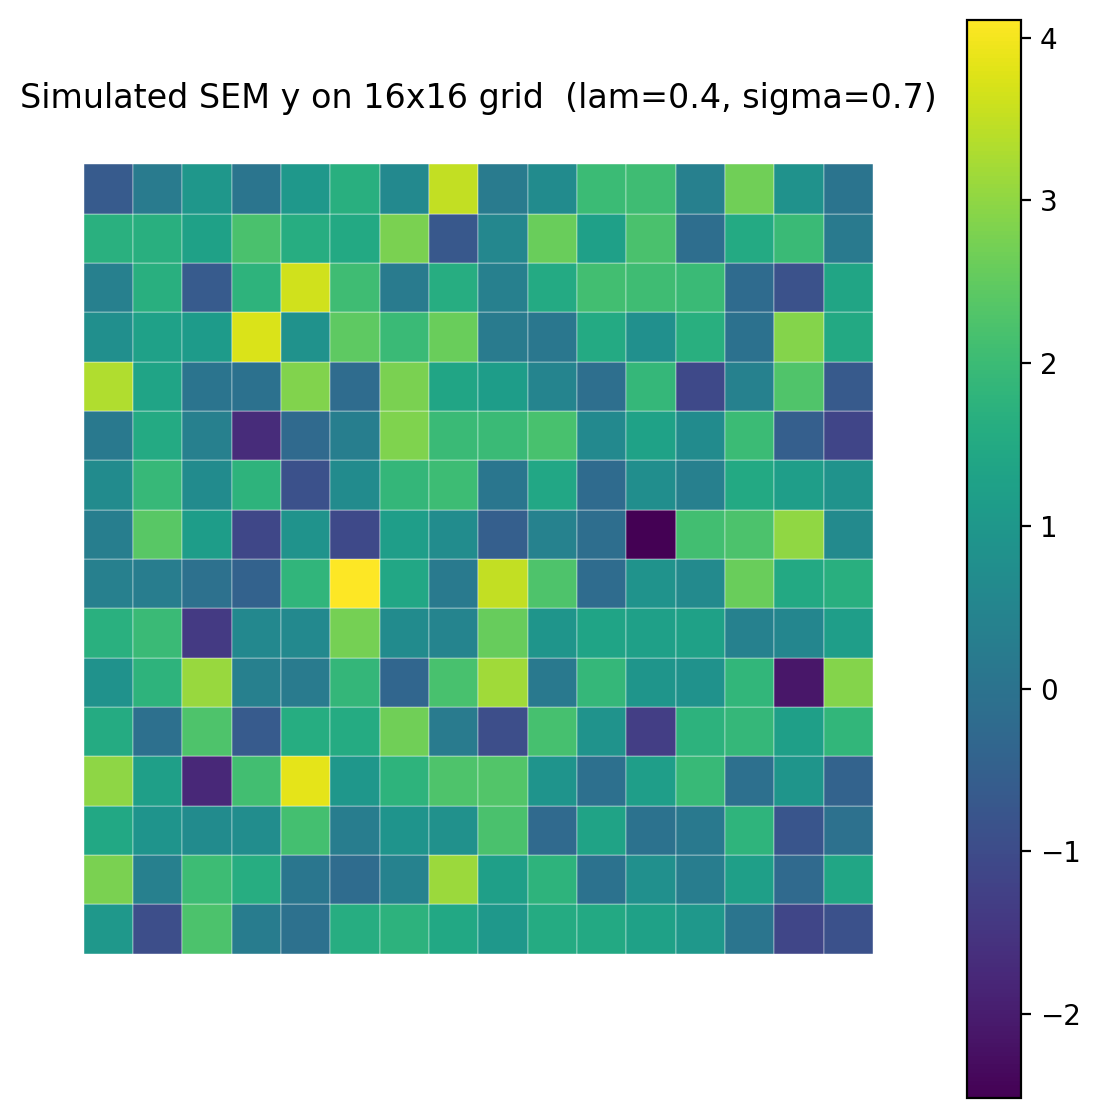

In [4]:
gdf, y, X, W = simulate_sem_data(seed=PROFILE_CFG["seed"], n_side=PROFILE_CFG["n_side"])

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
gdf.plot(
    column="y", cmap="viridis", legend=True, linewidth=0.15, edgecolor="white", ax=ax
)
ax.set_title(
    f"Simulated SEM y on {PROFILE_CFG['n_side']}x{PROFILE_CFG['n_side']} grid"
    f"  (lam={TRUE_LAM}, sigma={TRUE_SIGMA})"
)
ax.set_axis_off()
plt.show()

In [5]:
rows = []
for backend_name in BACKENDS:
    print(f"Profiling backend={backend_name}...")
    rows.append(fit_backend(backend_name, y, X, W))

results = pd.DataFrame(rows)
results["lam_abs_error"] = (results["lam_hat"] - TRUE_LAM).abs()
results = results.sort_values(
    ["available", "total_time_s"], ascending=[False, True], na_position="last"
).reset_index(drop=True)

display_cols = [
    "backend",
    "available",
    "total_time_s",
    "lam_hat",
    "lam_abs_error",
    "sigma_hat",
    "beta_rmse",
    "divergences",
    "has_log_likelihood",
    "error",
]
results[display_cols].round(
    {
        "total_time_s": 3,
        "lam_hat": 3,
        "lam_abs_error": 3,
        "sigma_hat": 3,
        "beta_rmse": 3,
    }
)

/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_factories.py:527: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)
Initializing NUTS using jitter+adapt_diag...


Profiling backend=c...


Multiprocess sampling (4 chains in 2 jobs)
NUTS: [lam, beta, sigma2]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_factories.py:527: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)
Initializing NUTS using jitter+adapt_diag...


Profiling backend=numba...


Multiprocess sampling (4 chains in 2 jobs)
NUTS: [lam, beta, sigma2]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 0 seconds.
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_factories.py:527: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)


Profiling backend=numpyro...
Profiling backend=blackjax...


/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_factories.py:527: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)


Profiling backend=nutpie...


/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_factories.py:527: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)


,backend,available,total_time_s,lam_hat,lam_abs_error,sigma_hat,beta_rmse,divergences,has_log_likelihood,error
0,numba,True,1.065,0.451,0.051,0.693,0.032,0,True,
1,nutpie,True,1.806,0.451,0.051,0.692,0.032,0,True,
2,blackjax,True,2.589,0.446,0.046,0.693,0.033,0,True,
3,c,True,3.642,0.451,0.051,0.693,0.032,0,True,
4,numpyro,True,5.057,0.448,0.048,0.693,0.033,0,True,


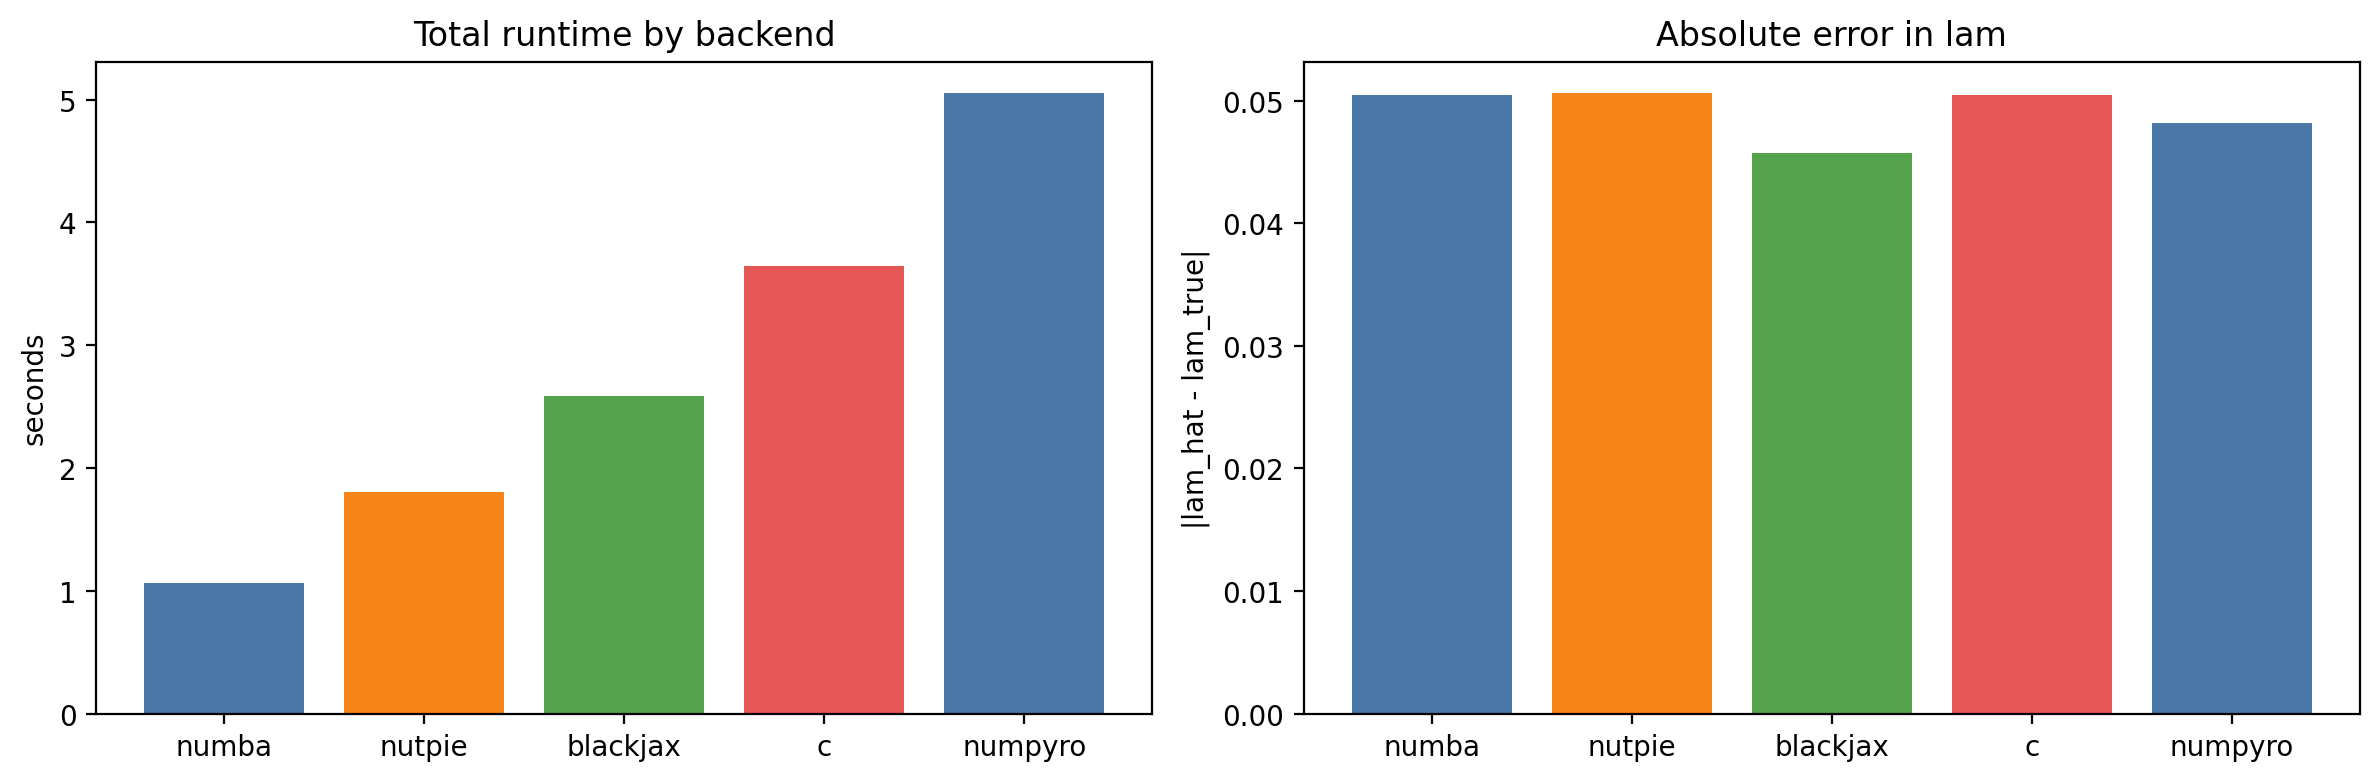

In [6]:
ok = results[results["total_time_s"].notna()].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if not ok.empty:
    palette = ["#4c78a8", "#f58518", "#54a24b", "#e45756"][: len(ok)]
    axes[0].bar(ok["backend"], ok["total_time_s"], color=palette)
    axes[0].set_title("Total runtime by backend")
    axes[0].set_ylabel("seconds")
    axes[1].bar(ok["backend"], ok["lam_abs_error"], color=palette)
    axes[1].set_title("Absolute error in lam")
    axes[1].set_ylabel("|lam_hat - lam_true|")
plt.tight_layout()
plt.show()

## Log-likelihood equivalence across backends

The `has_log_likelihood` column above must be `True` for every available backend — including JAX backends — confirming that PyMC's native log-likelihood capture works for SEM regardless of which sampler is used.

Below we check that the **per-observation posterior-mean log-likelihood** is consistent across backends, modulo Monte-Carlo noise from independent chains.

In [7]:
successful = {
    row["backend"]: row["idata"]
    for _, row in results.iterrows()
    if row["has_log_likelihood"]
}
print("Backends with native log_likelihood capture:", list(successful))

ll_means = {}
ll_totals = {}
for name, idata in successful.items():
    obs = idata.log_likelihood["obs"]
    obs_dim = [d for d in obs.dims if d not in ("chain", "draw")][0]
    ll_means[name] = obs.mean(("chain", "draw")).values
    ll_totals[name] = float(obs.sum(obs_dim).mean(("chain", "draw")).values)

summary = pd.DataFrame(
    {
        "backend": list(ll_totals),
        "mean_total_loglik": [ll_totals[k] for k in ll_totals],
        "mean_per_obs_loglik": [float(ll_means[k].mean()) for k in ll_means],
    }
)
summary.round(4)

Backends with native log_likelihood capture: ['numba', 'nutpie', 'blackjax', 'c', 'numpyro']


,backend,mean_total_loglik,mean_per_obs_loglik
0,numba,-275.8633,-1.0776
1,nutpie,-275.7687,-1.0772
2,blackjax,-275.7756,-1.0772
3,c,-275.8633,-1.0776
4,numpyro,-275.8618,-1.0776


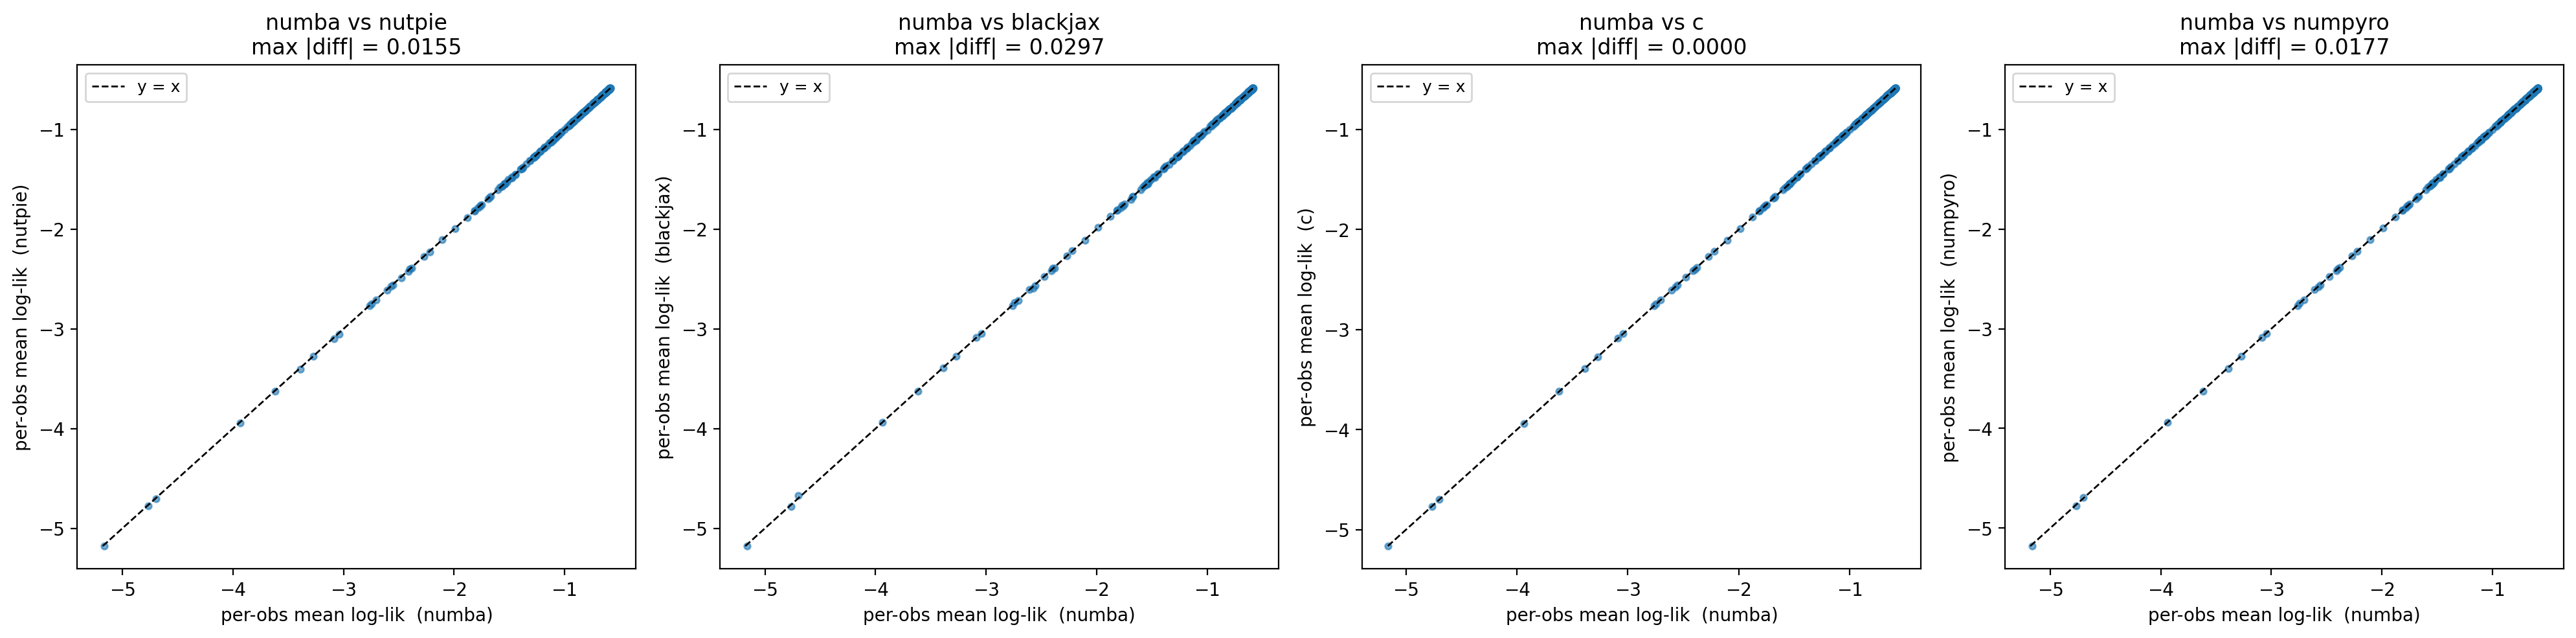

In [8]:
names = list(successful)
if len(names) >= 2:
    ref = names[0]
    others = names[1:]
    fig, axes = plt.subplots(
        1, len(others), figsize=(5 * len(others), 5), squeeze=False
    )
    for ax, other in zip(axes[0], others):
        x = ll_means[ref]
        y_arr = ll_means[other]
        ax.scatter(x, y_arr, s=12, alpha=0.6)
        lo = float(min(x.min(), y_arr.min()))
        hi = float(max(x.max(), y_arr.max()))
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
        ax.set_xlabel(f"per-obs mean log-lik  ({ref})")
        ax.set_ylabel(f"per-obs mean log-lik  ({other})")
        max_abs = float(np.max(np.abs(x - y_arr)))
        ax.set_title(f"{ref} vs {other}\nmax |diff| = {max_abs:.4f}")
        ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Need >=2 backends with log_likelihood for pairwise comparison.")

In [9]:
loo_rows = []
for name, idata in successful.items():
    loo = az.loo(idata)
    loo_rows.append(
        {
            "backend": name,
            "elpd_loo": float(loo.elpd_loo),
            "se": float(loo.se),
            "p_loo": float(loo.p_loo),
        }
    )
loo_df = pd.DataFrame(loo_rows).round(3)
loo_df

,backend,elpd_loo,se,p_loo
0,numba,-278.150,11.969,4.460
1,nutpie,-277.981,12.006,4.316
2,blackjax,-277.965,11.969,4.261
3,c,-278.150,11.969,4.460
4,numpyro,-278.175,12.005,4.499


In [10]:
if len(successful) >= 2:
    cmp = az.compare(successful, ic="loo")
    display(cmp)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
blackjax,0,-277.965475,4.261137,0.000000,1.000000e+00,11.969487,0.000000,False,log
nutpie,1,-277.981449,4.315785,0.015974,0.000000e+00,12.005709,0.089966,False,log
c,2,-278.149779,4.460481,0.184305,0.000000e+00,11.969022,0.084879,False,log
numba,3,-278.149779,4.460481,0.184305,0.000000e+00,11.969022,0.084879,False,log
numpyro,4,-278.175221,4.498922,0.209746,1.986027e-16,12.005298,0.073500,False,log


## Reading the results

Three things to verify:

1. **Native capture** — every available backend reports `has_log_likelihood = True`. Prior to the SEM `CustomDist` migration, JAX backends would have either crashed inside `pm.sampling.jax._get_log_likelihood` or silently produced an empty log-likelihood group.
2. **Posterior parity** — `lam_hat`, `sigma_hat`, and `beta_rmse` should be similar across backends. Small differences are expected (independent MCMC chains).
3. **Log-likelihood parity** — the pairwise scatter plots should hug the y=x line, and `az.compare` should report ELPD differences (`dse`) on the order of the within-backend SE — i.e. backends are statistically indistinguishable from each other.

The convention in the SEM `CustomDist.logp` is to distribute the spatial Jacobian `log|I - λW|` evenly across observations as `log|I - λW| / n`. The *sum* across observations equals the joint log-density; the per-point split is a bookkeeping convention shared with the manual NumPy fallback used on the C/Numba backend so that `az.loo` and `az.waic` numbers match across backends.